# **4. Phân tích SHAP**

## **4.1 Setup - Load model, data, các hàm SHAP**

In [14]:
# Import môi trường
import seaborn as sns
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import numpy as np
import warnings
import sys
warnings.filterwarnings('ignore')

In [15]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Thêm src vào path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [16]:
# 1. Tìm project_root (chứa folder 'src')
current = Path.cwd().resolve()
project_root = next((p for p in [current, *current.parents] if (p / "src").exists()), None)
if project_root is None:
    raise FileNotFoundError("Không tìm thấy thư mục 'src'")
sys.path.insert(0, str(project_root))
print("project_root =", project_root)

project_root = D:\Python\AIN701_Group_04\demo


In [17]:
# 2. Load model đã train (tự tìm, không cần biết chính xác path)
model_path = project_root / 'data' / 'models' / 'xgboost.pkl'  # kiểm tra đúng path em đã lưu lúc trước
best_model = joblib.load(model_path)
print("Đã load model:", type(best_model).__name__)

Đã load model: XGBClassifier


In [18]:
# 3. Load data đã xử lý
processed_dir = project_root / 'data' / 'processed'
X_train = pd.read_pickle(processed_dir / 'X_train.pkl')
X_test = pd.read_pickle(processed_dir / 'X_test.pkl')
y_train = pd.read_pickle(processed_dir / 'y_train.pkl')
y_test = pd.read_pickle(processed_dir / 'y_test.pkl')
print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (204277, 24)  X_test: (51070, 24)


In [19]:
# 4. Import hàm SHAP
from src.models.shap_analysis import (
    get_explainer, compute_shap_values, plot_global_summary, plot_global_bar,
    get_rejected_cases, plot_local_waterfall, get_top_features_for_case
)
from src.models.predict_model import load_model_and_features, predict_loan

THRESHOLD = 0.176  # đã chốt ở bước trước
figures_dir = project_root / 'src' / 'reports' / 'figures'

## **4.2 Global Explanation — Feature Importance tổng thể**

Đã tạo SHAP Explainer cho XGBoost model


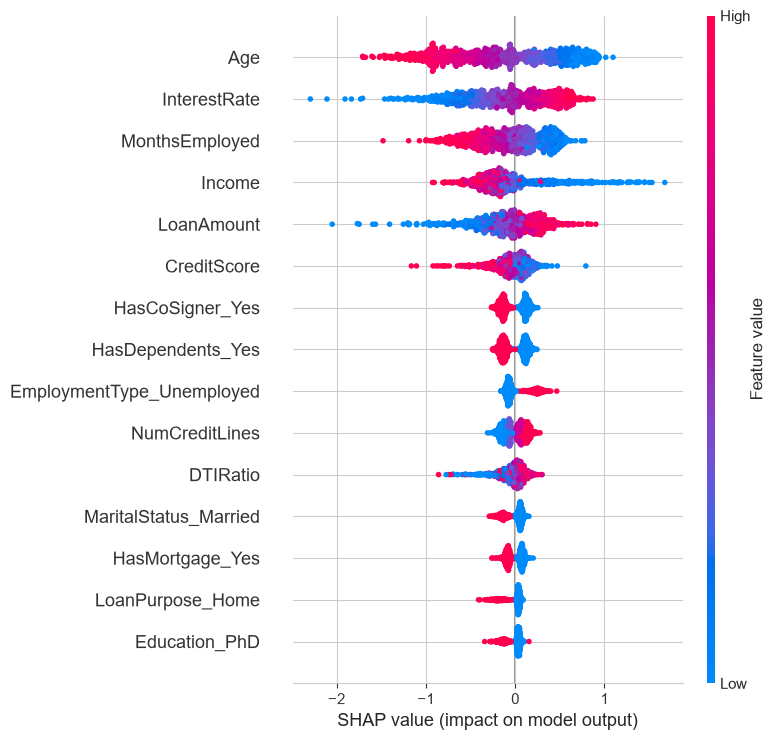

In [20]:
explainer = shap.TreeExplainer(best_model)
print("Đã tạo SHAP Explainer cho XGBoost model")

# Tính SHAP values cho 1000 mẫu ngẫu nhiên từ test set (đủ đại diện, nhanh hơn chạy hết 51k dòng)
X_sample, shap_values = compute_shap_values(explainer, X_test, sample_size=1000)

plot_global_summary(shap_values, X_sample, save_path=figures_dir / 'shap_summary.png')

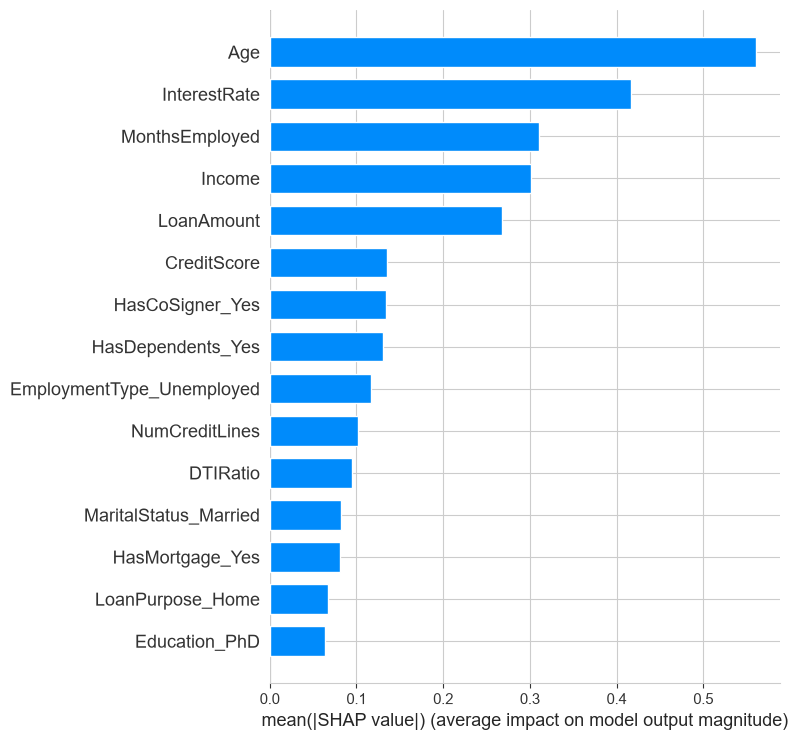

In [21]:
plot_global_bar(shap_values, X_sample, save_path=figures_dir / 'shap_importance_bar.png')

## **4.3 Local Explanation — Case bị từ chối thực tế trong tập test**

Số case bị từ chối trong mẫu 1000: 800


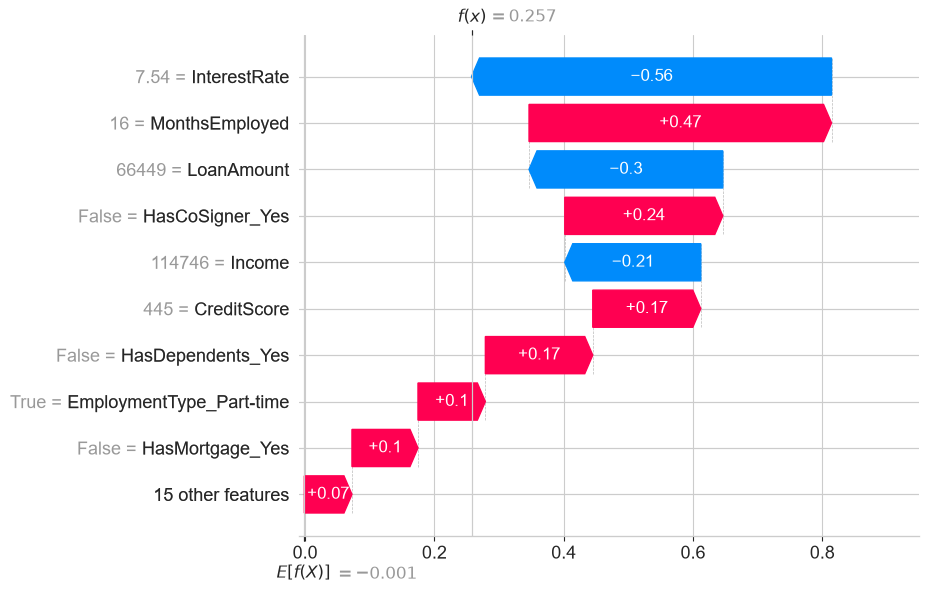

In [22]:
# Lấy các case bị model dự đoán "từ chối" (Default=1) theo threshold đã chốt, trong X_sample
rejected_idx, proba = get_rejected_cases(best_model, X_sample, THRESHOLD)
print(f"Số case bị từ chối trong mẫu {len(X_sample)}: {len(rejected_idx)}")

case_idx = rejected_idx[0]
plot_local_waterfall(explainer, shap_values, X_sample, case_idx,
                      save_path=figures_dir / 'shap_waterfall_example.png')

In [23]:
top_features = get_top_features_for_case(shap_values, X_sample, case_idx)
print(f"Xác suất default của case này: {proba[case_idx]:.4f}")
print(top_features)

Xác suất default của case này: 0.5640
           feature   value  shap_value
0     InterestRate    7.54   -0.556812
1   MonthsEmployed      16    0.467888
2       LoanAmount   66449   -0.299706
3  HasCoSigner_Yes   False    0.244411
4           Income  114746   -0.210344
